In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


In [ ]:
def manual_bilateral_filter(image, d, sigma_s, sigma_r):
    h, w = image.shape
    output = np.zeros_like(image, dtype=float)
    pad = d // 2
    padded = np.pad(image, pad, mode='reflect').astype(float)
    
    x, y = np.meshgrid(np.arange(d) - pad, np.arange(d) - pad)
    spatial_weights = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))
    
    for i in range(h):
        for j in range(w):
            region = padded[i : i+d, j : j+d]  # Extract neighborhood
            
            # Calculate range weights based on intensity difference
            intensity_diff = region - padded[i + pad, j + pad]
            range_weights = np.exp(-(intensity_diff**2) / (2 * sigma_r**2))
            
            weights = spatial_weights * range_weights  # Combined weights
            output[i, j] = np.sum(region * weights) / np.sum(weights) # Normalize and compute new pixel value            
    return output.astype(np.uint8)

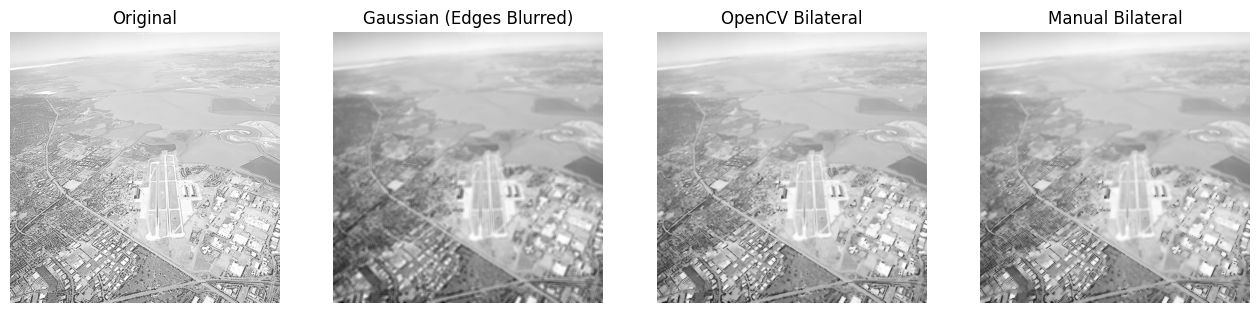

In [ ]:
d = 9          # Diameter
sigma_s = 75   # Spatial Sigma
sigma_r = 75   # Range Sigma

img = cv2.imread('runway.png', cv2.IMREAD_GRAYSCALE)

# (b) Gaussian Smoothing
gaussian = cv2.GaussianBlur(img, (d, d), sigma_s)

# (c) OpenCV Bilateral
bilateral_cv = cv2.bilateralFilter(img, d, sigma_r, sigma_s)

# (d) Manual Bilateral
bilateral_manual = manual_bilateral_filter(img, d, sigma_s, sigma_r)

# --- Visualization ---
plt.figure(figsize=(16, 4))
titles = ["Original", "Gaussian (Edges Blurred)", "OpenCV Bilateral", "Manual Bilateral"]
images = [img, gaussian, bilateral_cv, bilateral_manual]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()